# Section A — SQL Basics (SELECT, Constraints, Primary Keys)
--- 
# Q1. Write a query to display all columns and rows from the customer's table.

#### Code : SELECT * FROM customers;

### Output

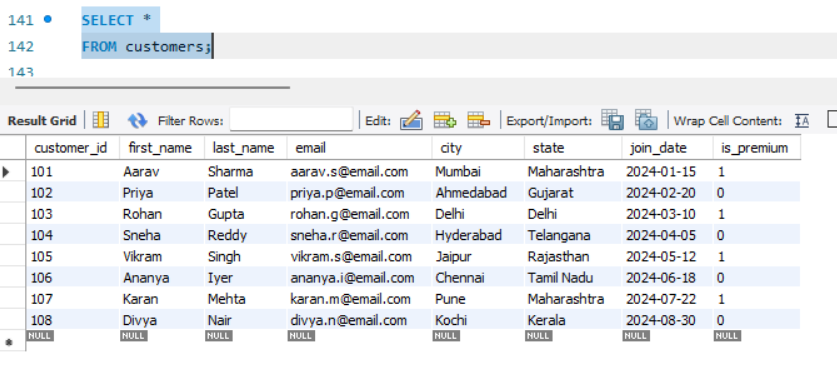



# Q2. Retrieve only the first_name, last_name, and city of all customers.

#### Code : SELECT first_name, last_name, city FROM customers;

### Output

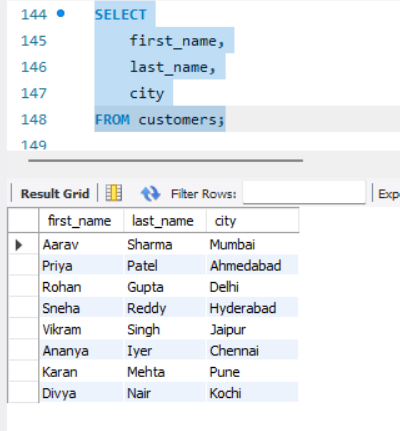


# Q3. List all unique categories available in the products table.

#### Code : SELECT DISTINCT category FROM products;

### Output

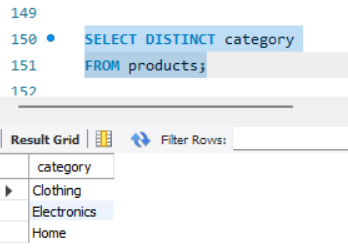


# Q4. Identify the Primary Key of each table in the schema.
# Explain why a Primary Key must be unique and NOT NULL.

#### Code : SHOW KEYS FROM customers WHERE Key_name = 'PRIMARY';
### Output
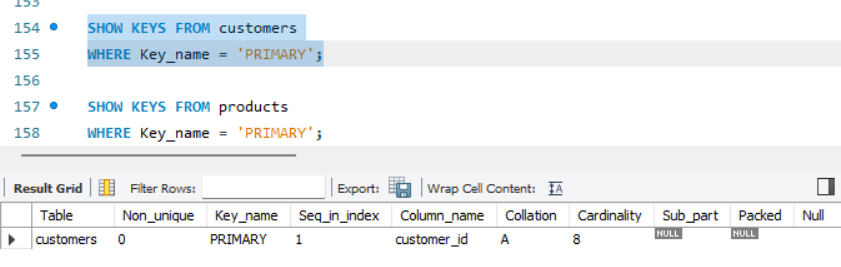

#### Code : SHOW KEYS FROM products WHERE Key_name = 'PRIMARY';

### Output
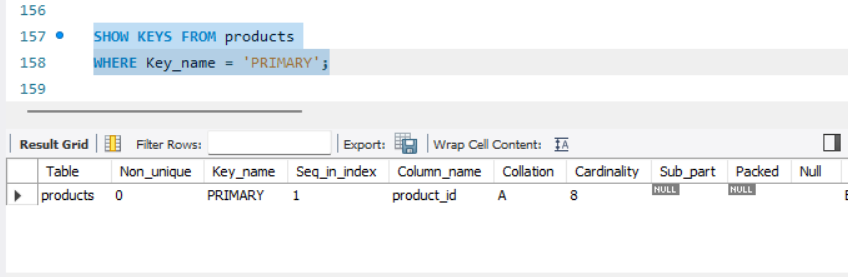

#### Code : SHOW KEYS FROM orders WHERE Key_name = 'PRIMARY';
### Output
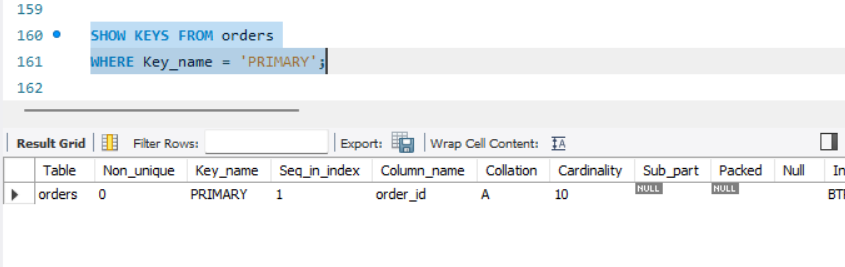

#### Code : SHOW KEYS FROM order_items WHERE Key_name = 'PRIMARY';
### Output
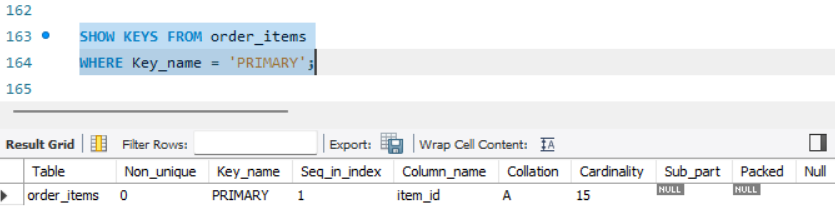


Explanation:

The primary key of each table is:

customers   -> customer_id
products    -> product_id
orders      -> order_id
order_items -> item_id

A primary key is used to identify each record in a table.
Every value must be unique so that no two records are the same.
It also cannot be NULL because every record must have its own ID.




# Q5. What constraints are applied to the email column in the customers table?
# What would happen if you tried to insert a duplicate email?

#### Code : INSERT INTO customers VALUES (109,'Rahul','Kumar','aarav.s@email.com','Lucknow','Uttar Pradesh','2024-09-01',FALSE );
### Output
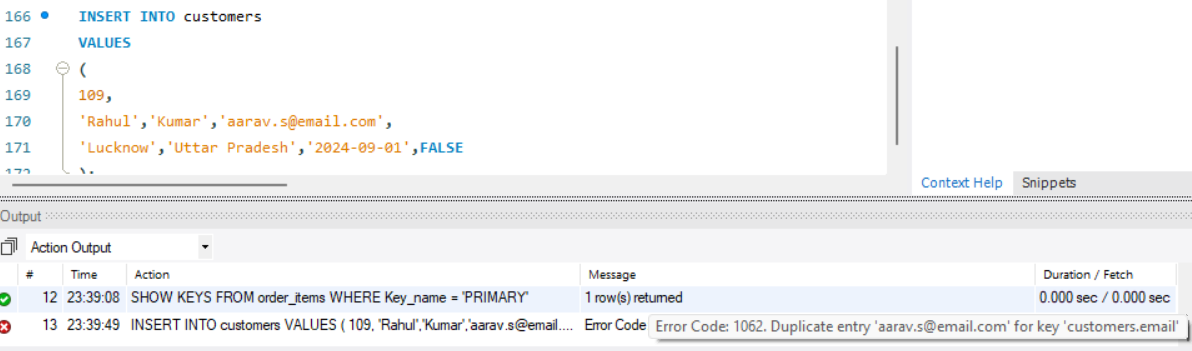


Explanation:

The email column has two constraints:

1. UNIQUE
2. NOT NULL

UNIQUE makes sure the same email cannot be stored more than once.

NOT NULL makes sure every customer has an email address.

If I try to insert an email that already exists,
MySQL shows a duplicate entry error and the new record is not added.




# Q6. Try inserting a product with unit_price = -50.
# What happens and which constraint prevents it?
# Write both the INSERT statement and explain the error.

#### Code : INSERT INTO products VALUES ( 209,'Test Product','Electronics','TestBrand',-50,100 );
### Output
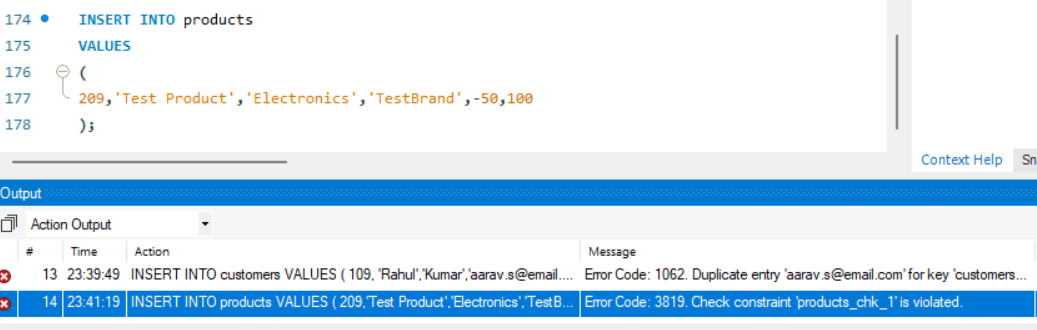


Explanation:

This query will fail because the product price cannot be negative.

The unit_price column has a CHECK constraint that only allows
values greater than zero.

Since I entered -50, MySQL rejects the record and displays an error.


# Section B - Filtering & Optimization (WHERE, Indexes)
--- 

# Q7. Retrieve all orders with status = 'Delivered'.

#### Code : SELECT * FROM orders WHERE status = 'Delivered';
### Output

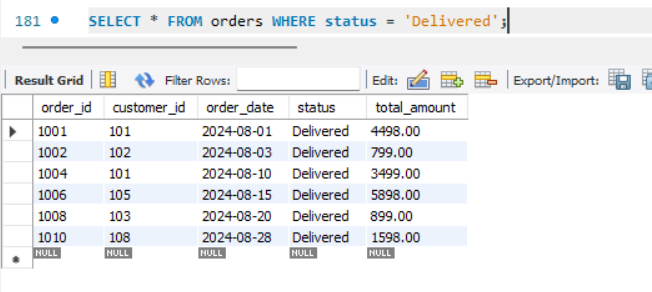

# Q8. Find all products in the 'Electronics' category with a unit_price greater than ₹2000.

#### Code : SELECT * FROM products WHERE category = 'Electronics' AND unit_price > 2000;
### Output

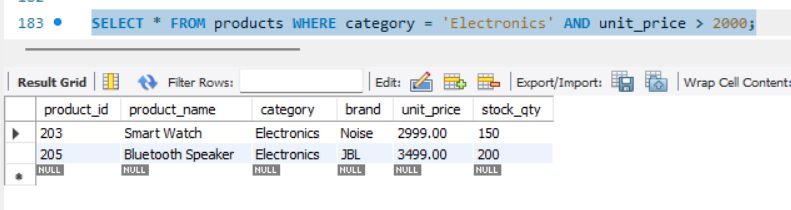


# Q9. List all customers who joined in the year 2024 and belong to the state 'Maharashtra'.

#### Code : SELECT *FROM customers WHERE join_date BETWEEN '2024-01-01' AND '2024-12-31'AND state = 'Maharashtra';
### Output

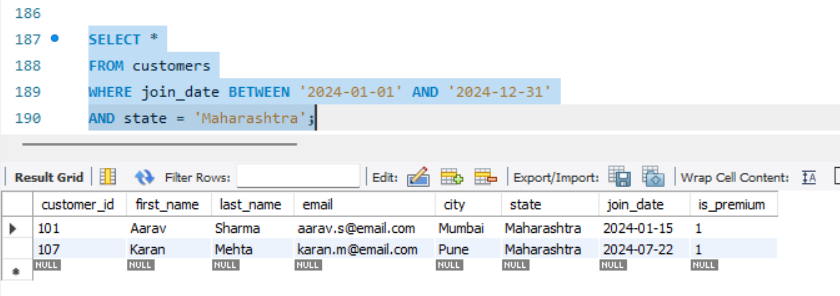


# Q10. Find all orders placed between '2024-08-10' and '2024-08-25' (inclusive) that are NOT cancelled.

#### Code : SELECT * FROM orders WHERE order_date BETWEEN '2024-08-10' AND '2024-08-25'AND status <> 'Cancelled';
### Output
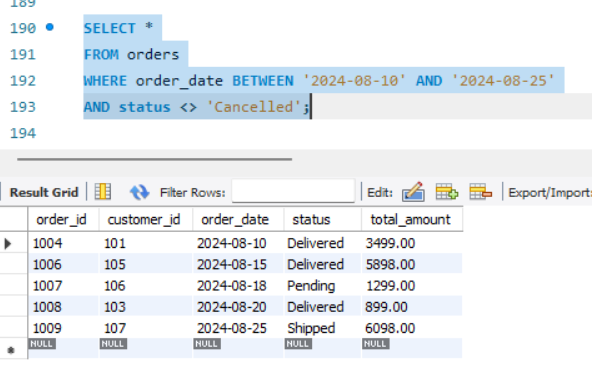


# Q11. Explain what the index idx_orders_date does.
# How would it improve the performance of a query that filters orders by order_date?
# Write a sample query that would benefit from this index.

#### Code : SELECT * FROM orders WHERE order_date = '2024-08-15';
### Output
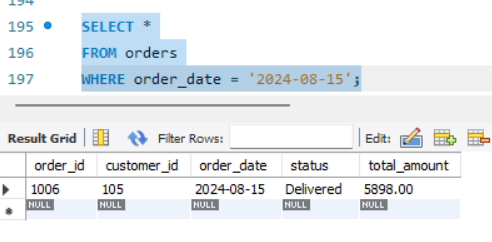

Explanation:

The idx_orders_date index is created on the order_date column.

When a query searches records using order_date,
MySQL can find the matching rows much faster instead of checking
every row in the table.

This helps improve performance, especially when the table
contains a large number of records.




# Q12. If you run:
# SELECT * FROM customers WHERE YEAR(join_date) = 2024;
# would the index on join_date be used?
# Explain why or why not, and rewrite the query to be index-friendly (SARGable).


-- Query using YEAR()

#### Code : SELECT * FROM customers WHERE YEAR(join_date) = 2024;
### Output
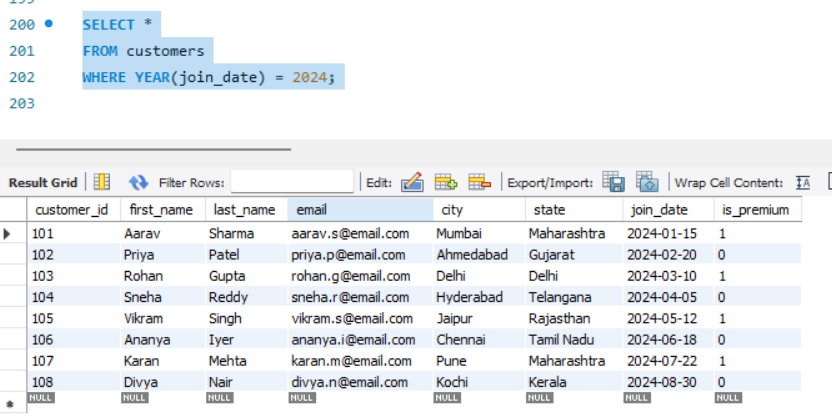

-- Index-friendly query

#### Code : SELECT * FROM customers WHERE join_date BETWEEN '2024-01-01' AND '2024-12-31';
### Output
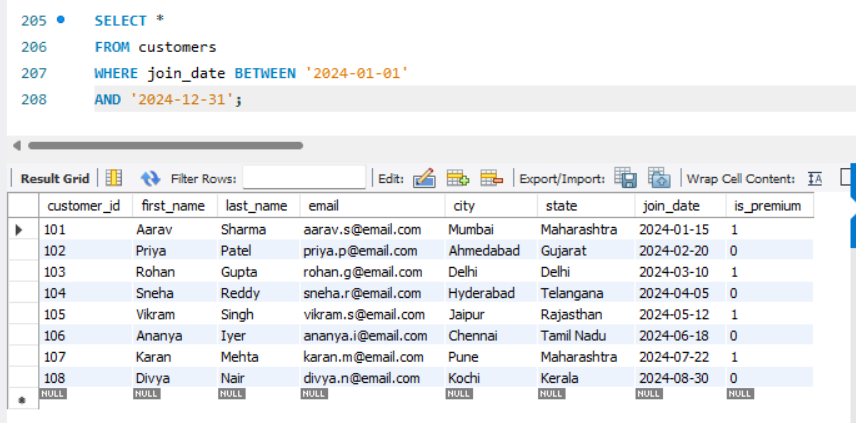


Explanation:

Using YEAR(join_date) makes MySQL calculate the year
for every row before filtering the data.

Because of this, the database may not use the index efficiently.

Using a date range allows MySQL to search directly
through the indexed values, so the query performs better.


# Section C - Aggregation (GROUP BY, SUM, COUNT, AVG, MIN, MAX)
--- 


# Q13. Count the total number of orders in the orders table.

#### Code : SELECT COUNT(*) AS total_orders FROM orders;
### Output
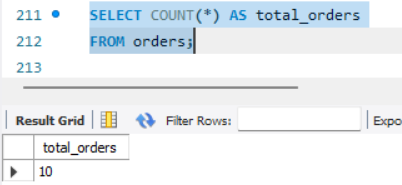


# Q14. Find the total revenue (SUM of total_amount) from all 'Delivered' orders.

#### Code : SELECT SUM(total_amount) AS total_revenue FROM orders WHERE status = 'Delivered';
### Output
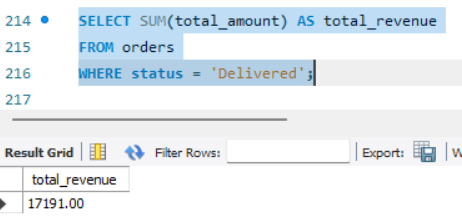


# Q15. Calculate the average unit_price of products in each category.

#### Code : SELECT category, AVG(unit_price) AS average_price FROM products GROUP BY category;
### Output
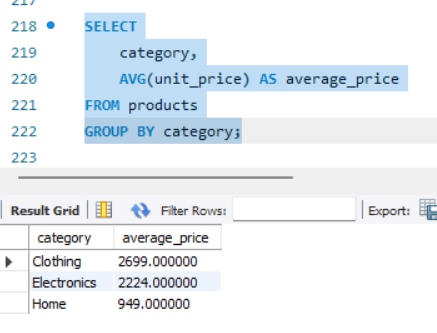


# Q16. For each order status, find the count of orders and the total revenue.
# Sort the result by total revenue in descending order.

#### Code :  SELECT status,COUNT(*) AS total_orders,SUM(total_amount) AS total_revenue FROM orders GROUP BY status ORDER BY total_revenue DESC;
### Output
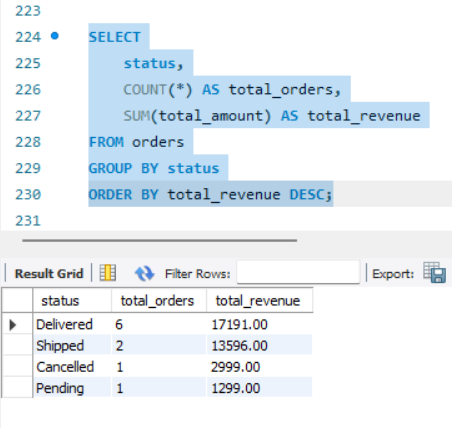


# Q17. Find the most expensive (MAX) and cheapest (MIN) product in each category.

#### Code :  SELECT category, MAX(unit_price) AS highest_price, MIN(unit_price) AS lowest_price FROM products GROUP BY category;
### Output
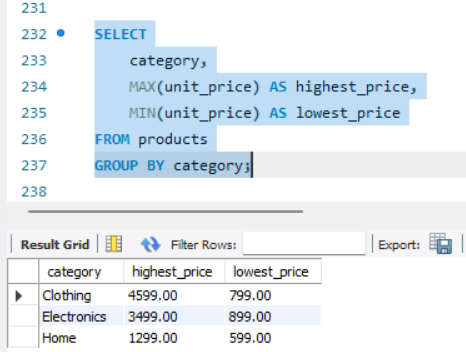


# Q18. List all product categories where the average unit_price is greater than ₹2000.
# (Hint: Use HAVING clause)

#### Code : SELECT category, AVG(unit_price) AS average_price FROM products GROUP BY category HAVING AVG(unit_price) > 2000;
### Output
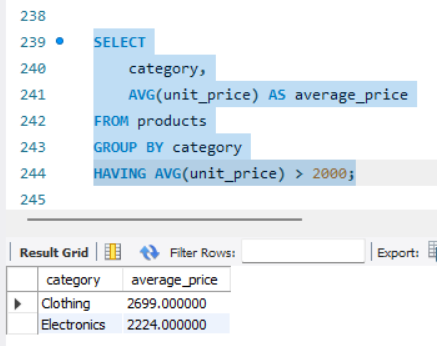

# Section D - Joins & Relationships
--- 


# Q19. Write an INNER JOIN query to display each order along with the customer's
# first_name and last_name.
# Show: order_id, order_date, first_name, last_name, total_amount.

#### Code : SELECT o.order_id,
    o.order_date, c.first_name, c.last_name, o.total_amount FROM orders o INNER JOIN customers c ON o.customer_id = c.customer_id;
### Output
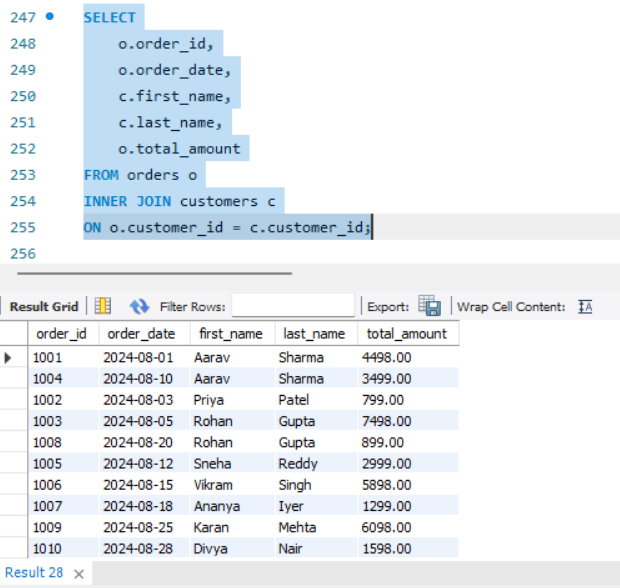


# Q20. Using a LEFT JOIN, list ALL customers and their orders (if any).
# Customers with no orders should still appear with NULL values for order columns.

#### Code : SELECT c.customer_id, c.first_name, c.last_name, o.order_id, o.order_date, o.status FROM customers c LEFT JOIN orders o ON c.customer_id = o.customer_id;
### Output
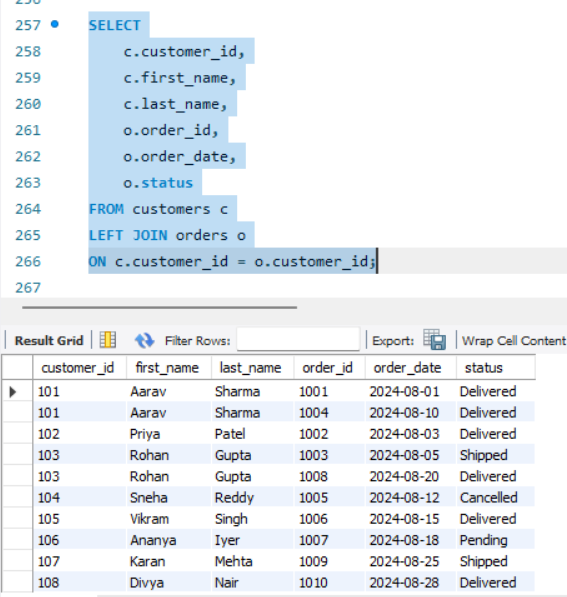


# Q21. Write a query using JOINs across three tables
# (orders → order_items → products)
# to show:
# order_id, product_name, quantity, unit_price, and discount_pct for each order item.

#### Code : SELECT o.order_id, p.product_name, oi.quantity, oi.unit_price, oi.discount_pct FROM orders o INNER JOIN order_items oi ON o.order_id = oi.order_id INNER JOIN products p ON oi.product_id = p.product_id;
### Output
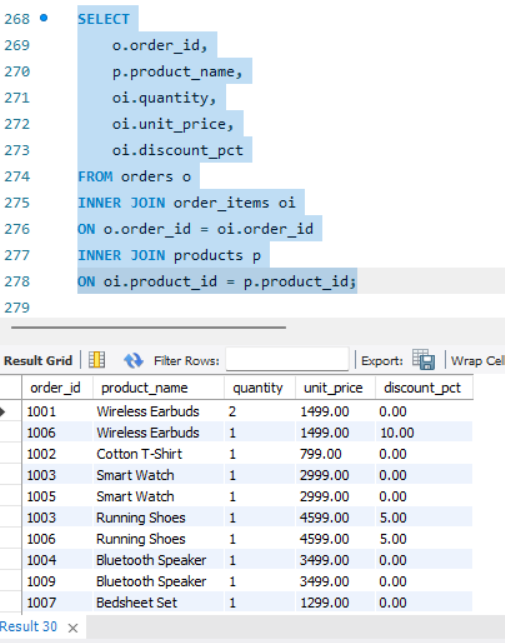


# Q22. Explain the difference between LEFT JOIN and RIGHT JOIN
# with an example from this schema.
# When would you use a FULL OUTER JOIN?


Explanation:

LEFT JOIN returns all records from the left table
and the matching records from the right table.

Example:
If we use customers as the left table,
every customer will be displayed even if they have not placed any order.

RIGHT JOIN works in the opposite way.
It returns all records from the right table
and the matching records from the left table.

A FULL OUTER JOIN returns all records from both tables.
It is useful when we want to see both matching
and non-matching records from both sides.

Note:
MySQL does not support FULL OUTER JOIN directly.
It can be achieved by combining LEFT JOIN and RIGHT JOIN using UNION.




# Q23. Identify all Foreign Key relationships in the schema.
# Explain what would happen if you tried to insert an order
# with customer_id = 999 (which doesn't exist in customers).


Foreign Key Relationships

orders.customer_id
        references
customers.customer_id

order_items.order_id
        references
orders.order_id

order_items.product_id
        references
products.product_id

If customer_id = 999 does not exist in the customers table,
MySQL will not allow the record to be inserted.

It will return a Foreign Key Constraint error
because every order must belong to an existing customer.


-- Example

INSERT INTO orders
VALUES
(
1011,
999,
'2024-09-01',
'Pending',
1598.00
);

# Section E - Advanced Concepts (CASE, ACID, Transactions)
--- 


# Q24. Write a query using CASE to classify products into price tiers:
# • 'Budget'    → unit_price < 1000
# • 'Mid-Range' → unit_price BETWEEN 1000 AND 3000
# • 'Premium'   → unit_price > 3000
# Display: product_name, unit_price, price_tier.

#### Code : SELECT product_name, unit_price, CASE WHEN unit_price < 1000 THEN 'Budget' WHEN unit_price BETWEEN 1000 AND 3000 THEN 'Mid-Range' ELSE 'Premium' END AS price_tier FROM products;
### Output
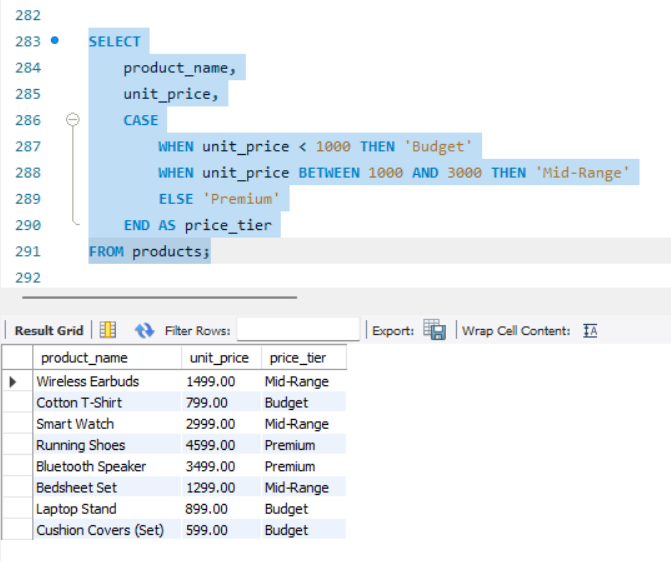


# Q25. Using a CASE statement inside an aggregate function,
# count how many orders are 'Delivered' vs 'Not Delivered'
# (all other statuses). Display the result in a single row.

#### Code : SELECT SUM(CASE WHEN status = 'Delivered' THEN 1 ELSE 0 END) AS Delivered_Orders, SUM(CASE WHEN status <> 'Delivered' THEN 1 ELSE 0 END) AS Not_Delivered_Orders FROM orders;
### Output
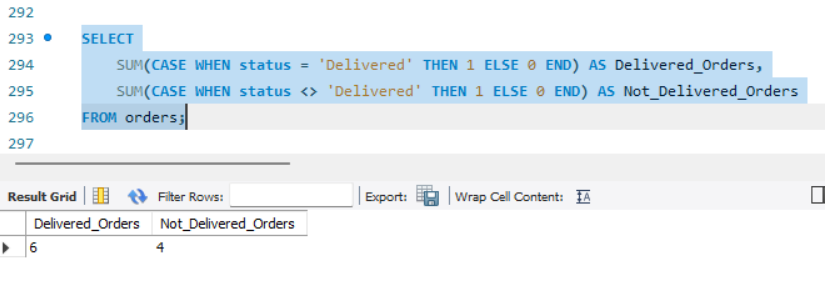

# Q26. Explain each letter of ACID:
# • A – Atomicity
# • C – Consistency
# • I – Isolation
# • D – Durability
# Give a real-world example (e.g., bank transfer)
# showing why each property is important.


Explanation:

A - Atomicity

Atomicity means all steps of a transaction are completed together.
If one step fails, the whole transaction is cancelled.

Example:
During a bank transfer, if the money is deducted from one account
but cannot be added to the other account, the transaction is rolled back.


C - Consistency

Consistency means the database always stays in a valid state.
The data should follow all rules and constraints.

Example:
A customer order cannot be created with a customer_id
that does not exist in the customers table.


I - Isolation

Isolation means multiple transactions can run at the same time
without affecting each other.

Example:
If two customers place orders at the same time,
both transactions should complete correctly without mixing data.


D - Durability

Durability means once a transaction is committed,
the changes are permanently saved.

Example:
If the system crashes after an order is placed,
the order should still be available after restarting the database.




# Q27. Write a SQL transaction that does the following atomically:
# 1. Insert a new order
# 2. Insert two order items
# 3. Update the stock quantity
# 4. If any step fails, rollback the transaction.
# Otherwise, commit.

#### Code : START TRANSACTION;

INSERT INTO orders
VALUES
(
1011,
102,
CURDATE(),
'Pending',
1598.00
);

INSERT INTO order_items
VALUES
(
5016,
1011,
206,
1,
1299.00,
0
);

INSERT INTO order_items
VALUES
(
5017,
1011,
208,
1,
299.00,
0
);

UPDATE products
SET stock_qty = stock_qty - 1
WHERE product_id = 206;

UPDATE products
SET stock_qty = stock_qty - 1
WHERE product_id = 208;

COMMIT;


If any statement fails before COMMIT,
the transaction should be rolled back.

Example:

ROLLBACK;
